# HW1: Классификация текстов по топикам (Lenta.ru News)

**Задача:** Классификация новостных статей по тематическим категориям

**Датасет:** lenta-ru-news (через библиотеку Corus)

---

## 0. Настройка окружения и импорты

In [2]:
# Фиксируем random_state для воспроизводимости
RANDOM_STATE = 42

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# Фиксируем seed
np.random.seed(RANDOM_STATE)

In [3]:
from corus import load_lenta2

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    classification_report, 
    confusion_matrix
)
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns

import re
import pymorphy3
import nltk

nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

RUSSIAN_STOPWORDS = set(stopwords.words('russian'))

## 1. Загрузка данных

In [4]:
DATA_PATH = 'lenta-ru-news.csv.bz2'

records = list(tqdm(load_lenta2(DATA_PATH), desc='Загрузка данных'))
print(f'Всего записей: {len(records):,}')

Загрузка данных: 800975it [00:47, 17016.48it/s]

Всего записей: 800,975


In [5]:
df = pd.DataFrame([
    {
        'title': r.title,
        'text': r.text,
        'topic': r.topic
    }
    for r in records
])

print(f'Размер датасета: {df.shape}')
df.head()

Размер датасета: (800975, 3)


,title,text,topic
0,1914. Русские войска вступили в пределы Венгрии,Бои у Сопоцкина и Друскеник закончились отступ...,Библиотека
1,1914. Празднование столетия М.Ю. Лермонтова от...,"Министерство народного просвещения, в виду про...",Библиотека
2,1914. Das ist Nesteroff!,"Штабс-капитан П. Н. Нестеров на днях, увидев в...",Библиотека
3,1914. Бульдог-гонец под Льежем,Фотограф-корреспондент Daily Mirror рассказыва...,Библиотека
4,1914. Под Люблином пойман швабский зверь,"Лица, приехавшие в Варшаву из Люблина, передаю...",Библиотека


## 2. Exploratory Data Analysis (EDA)

In [6]:
# Базовая статистика
print('Пропуски в данных:')
print(df.isnull().sum())
print()
print(f'Уникальных топиков: {df["topic"].nunique()}')

Пропуски в данных:
title    0
text     0
topic    0
dtype: int64

Уникальных топиков: 24


Распределение по топикам:
topic
Россия               160445
Мир                  136621
Экономика             79528
Спорт                 64413
                      62002
Культура              53797
Бывший СССР           53402
Наука и техника       53136
Интернет и СМИ        44663
Из жизни              27605
Дом                   21734
Силовые структуры     19596
Ценности               7766
Бизнес                 7399
Путешествия            6408
69-я параллель         1268
Крым                    666
Культпросвет            340
Легпром                 114
Библиотека               65
Оружие                    3
ЧМ-2014                   2
Сочи                      1
МедНовости                1
Name: count, dtype: int64


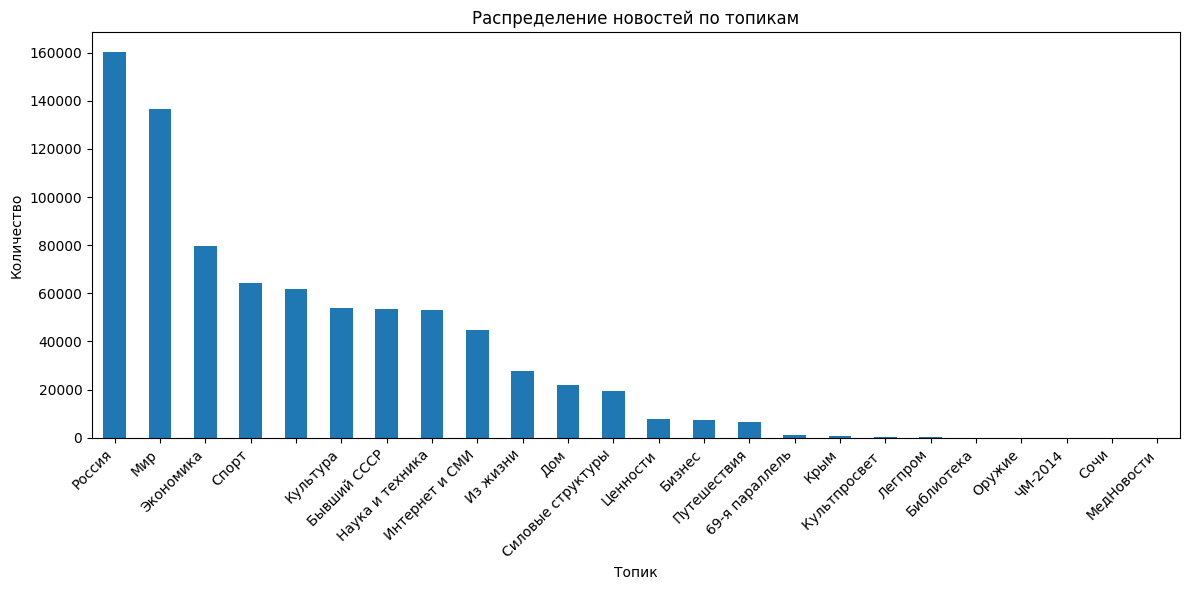

In [7]:
# Распределение классов
topic_counts = df['topic'].value_counts()
print('Распределение по топикам:')
print(topic_counts)

plt.figure(figsize=(12, 6))
topic_counts.plot(kind='bar')
plt.title('Распределение новостей по топикам')
plt.xlabel('Топик')
plt.ylabel('Количество')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
# Посмотрим подробнее на тексты без топиков
df_without_topic = df[df['topic'] == '']
df_without_topic.head()

,title,text,topic
112873,Путин повысил довольствие военнослужащим и пен...,Президент РФ Владимир Путин подписал указы о п...,
112894,Французы перестали понимать своих бюрократов,Во Франции опубликован словарь из 3 тысяч бюро...,
113287,Московские левые отметили 23 февраля шествием ...,23 февраля в Москве прошли праздничные митинги...,
114018,Исправление ошибок монетизации обошлось бюджет...,Председатель комитета Госдумы по аграрным вопр...,
114451,"Люксембург недоволен экономическим пактом, раз...",Министр финансов Люксембурга Жан-Клод Джанкер ...,


Видим порядка 70к текстов без топиков. Судя по заголовкам и текстам, их можно было отнести к существующим топикам, возможно, это недоразмеченная часть датасета.   
Уберем их из датасета. Причины:
  1. Это искусственный класс - модель будет учиться предсказывать "отсутствие метки", а не семантику текста                                      
  2. 70k - это ~9% данных, слишком много для "шума", но при этом они будут путать модель            

  Кроме того, видим темы с малым количеством текстов. Уберем все, где меньше 100, это: Библиотека, Оружие, ЧМ-2014, Сочи, Медновости. На фоне тем с более, чем 100к текстов эти будут восприниматься как шум, качество по ним, скорее всего, не вытянуть даже балансировкой классов, аугментация - оверхед для нашей задачи и сделать ее на менее, чем 100 текстах будет проблематично. Возможно, стоит удалить темы с менее, чем 6к текстов.                                                                                                                    
                                                                                                                                              
  Почему удаление безопасно:                                                                                                                  
  - После удаления останется ~730k записей                                                                                                    
  - Нам нужно всего 100k для выборки - с запасом                                                                                              
  - Распределение реальных крупных топиков не пострадает                                  

In [9]:
MIN_CLASS_THRESHOLD = 6000

valid_topics = topic_counts[topic_counts >= MIN_CLASS_THRESHOLD].index

df_filtered = df[(df['topic'] != '') & (df['topic'].isin(valid_topics))]
print('Размер датасета после удаления неразмеченных текстов и малых тем:')
print(df_filtered.shape)

Размер датасета после удаления неразмеченных текстов и малых тем:
(736513, 3)


In [10]:
# Статистика по длине текстов
df_filtered['text_len'] = df_filtered['text'].str.len()
df_filtered['title_len'] = df_filtered['title'].str.len()

print('Статистика по длине текста:')
print(df_filtered['text_len'].describe())
print()
print('Статистика по длине заголовка:')
print(df_filtered['title_len'].describe())

Статистика по длине текста:
count    736513.000000
mean       1335.304058
std         554.639533
min           0.000000
25%         977.000000
50%        1257.000000
75%        1606.000000
max       55386.000000
Name: text_len, dtype: float64

Статистика по длине заголовка:
count    736513.000000
mean         55.640630
std          11.884929
min           9.000000
25%          47.000000
50%          56.000000
75%          64.000000
max         132.000000
Name: title_len, dtype: float64


Распределение по длинам:
text_len
1200    732
1142    728
1058    726
1177    722
1116    721
       ... 
3901      1
4090      1
5322      1
3611      1
7329      1
Name: count, Length: 5115, dtype: int64


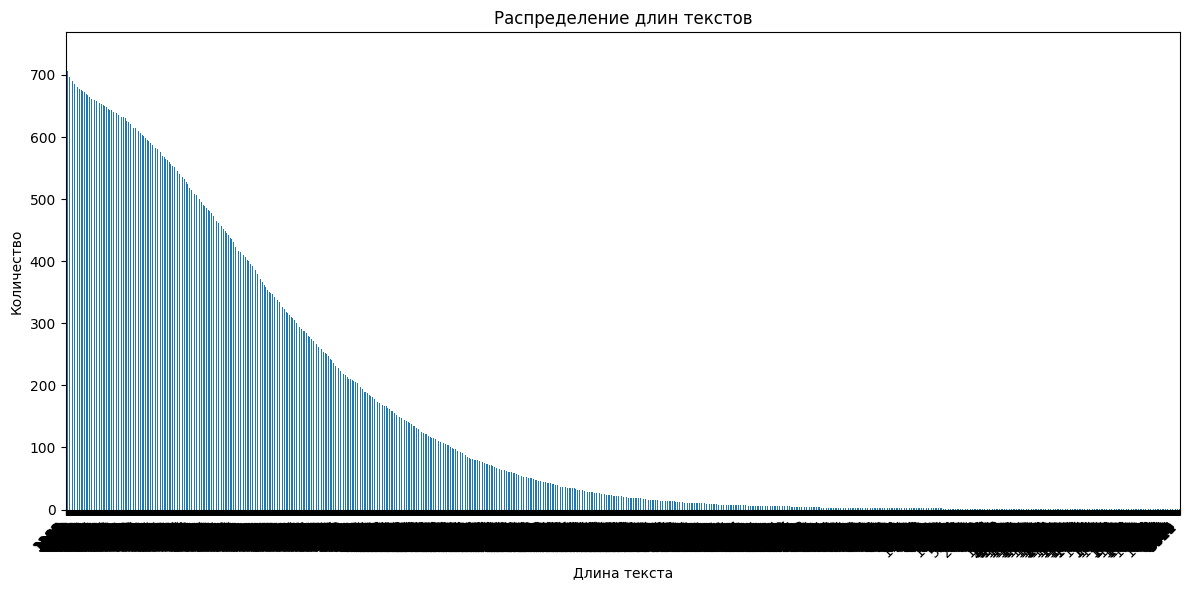

In [11]:
# Распределение длин текстов
text_len_counts = df_filtered['text_len'].value_counts()
print('Распределение по длинам:')
print(text_len_counts)

plt.figure(figsize=(12, 6))
text_len_counts.plot(kind='bar')
plt.title('Распределение длин текстов')
plt.xlabel('Длина текста')
plt.ylabel('Количество')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [12]:
# Длины по топикам
df_filtered['text_len'] = df_filtered['text'].str.len()

stats_by_topic = df_filtered.groupby('topic')['text_len'].describe()
print(stats_by_topic)

                      count         mean         std    min     25%     50%  \
topic                                                                         
Бизнес               7399.0  1718.473442  587.147344  247.0  1315.0  1632.0   
Бывший СССР         53402.0  1547.003408  856.198237    3.0  1100.0  1439.0   
Дом                 21734.0  1465.190071  563.110407  181.0  1104.0  1372.0   
Из жизни            27605.0  1142.635936  394.706809    3.0   884.0  1100.0   
Интернет и СМИ      44663.0  1376.753510  517.112125    3.0  1029.0  1292.0   
Культура            53797.0  1228.490808  455.819894    0.0   927.0  1155.0   
Мир                136621.0  1298.878738  504.538087    0.0   947.0  1242.0   
Наука и техника     53136.0  1457.010087  513.782558    3.0  1115.0  1393.0   
Путешествия          6408.0  1211.713171  364.714967  279.0   973.0  1177.0   
Россия             160445.0  1321.175512  590.545095    0.0   918.0  1246.0   
Силовые структуры   19596.0  1427.382782  470.748338

<Figure size 1200x600 with 0 Axes>

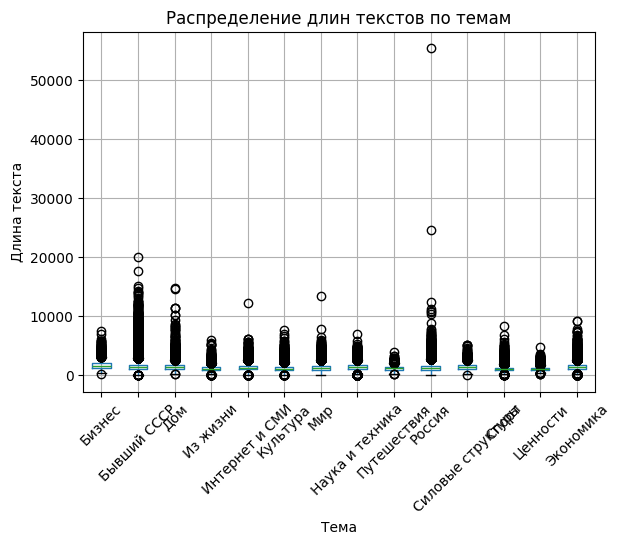

In [13]:
plt.figure(figsize=(12, 6))
df_filtered.boxplot(column='text_len', by='topic', rot=45)
plt.title('Распределение длин текстов по темам')
plt.suptitle('')
plt.xlabel('Тема')
plt.ylabel('Длина текста')
plt.show()

In [14]:
# 5 и 95 перцентили длины для каждой темы
q_by_topic = (
    df_filtered.groupby('topic')['text_len']
      .quantile([0.05, 0.95])
      .unstack(level=-1)  # сделать из MultiIndex нормальные колонки
)

q_by_topic.columns = ['q05', 'q95']

print('5 и 95 перцентили длины для каждой темы')
print(q_by_topic)

5 и 95 перцентили длины для каждой темы
                     q05      q95
topic                            
Бизнес             982.8  2712.20
Бывший СССР        624.0  2620.00
Дом                850.0  2350.00
Из жизни           582.0  1835.00
Интернет и СМИ     706.0  2318.00
Культура           646.0  2044.00
Мир                591.0  2194.00
Наука и техника    767.0  2379.25
Путешествия        671.0  1861.65
Россия             554.0  2343.00
Силовые структуры  765.0  2246.25
Спорт              646.0  1798.00
Ценности           725.0  1705.00
Экономика          791.0  2297.00


In [16]:
# 5 и 95 перцентили длины для всего датасета
global_q = df_filtered['text_len'].quantile([0.05, 0.95])
print("Глобальные 5 и 95 перцентили:")
print(global_q.rename({0.05: 'q05', 0.95: 'q95'}))

Глобальные 5 и 95 перцентили:
q05     631.0
q95    2272.0
Name: text_len, dtype: float64


Уберем выбросы по длине, судя по распределениям: глобальному и по топикам, можем взять единые границы для фильтрации. Так мы сохраним 90% данных и уберём только экстремальные выбросы (слишком короткие и слишком длинные).

In [17]:
q05, q95 = df_filtered['text_len'].quantile([0.05, 0.95])
df_filtered_len = df_filtered[(df_filtered['text_len'] >= q05) & (df_filtered['text_len'] <= q95)]
print(f"Оставлено {len(df_filtered_len):,} из {len(df_filtered):,} текстов ({100*len(df_filtered_len)/len(df_filtered):.1f}%)")

Оставлено 662,936 из 736,513 текстов (90.0%)


<Figure size 1200x600 with 0 Axes>

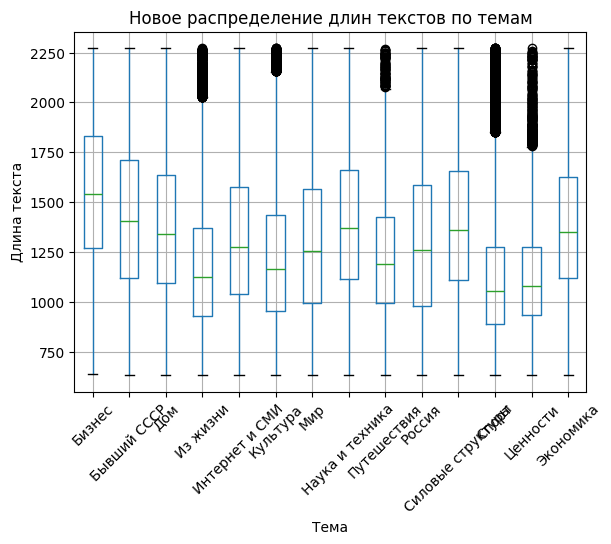

In [18]:
plt.figure(figsize=(12, 6))
df_filtered_len.boxplot(column='text_len', by='topic', rot=45)
plt.title('Новое распределение длин текстов по темам')
plt.suptitle('')
plt.xlabel('Тема')
plt.ylabel('Длина текста')
plt.show()

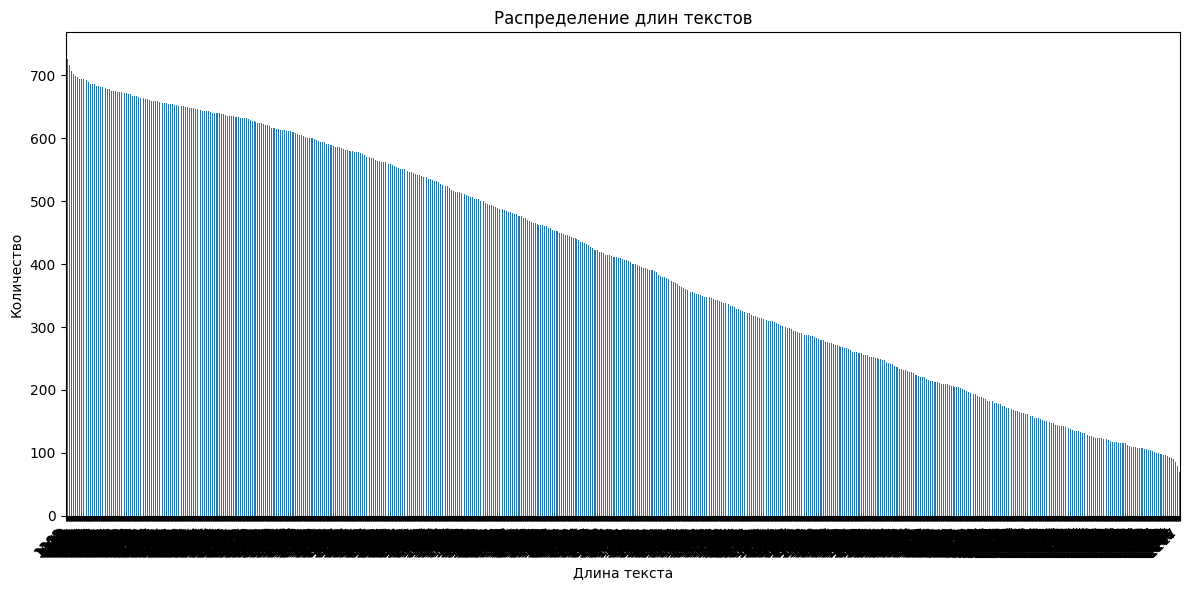

In [19]:
# Новое распределение длин текстов общее
text_len_counts = df_filtered_len['text_len'].value_counts()

plt.figure(figsize=(12, 6))
text_len_counts.plot(kind='bar')
plt.title('Распределение длин текстов')
plt.xlabel('Длина текста')
plt.ylabel('Количество')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Распределение по топикам:
topic
Россия               0.207981
Мир                  0.184525
Экономика            0.111243
Спорт                0.091541
Культура             0.075312
Наука и техника      0.073043
Бывший СССР          0.068284
Интернет и СМИ       0.061581
Из жизни             0.038326
Дом                  0.030587
Силовые структуры    0.027478
Ценности             0.011337
Бизнес               0.009577
Путешествия          0.009185
Name: proportion, dtype: float64


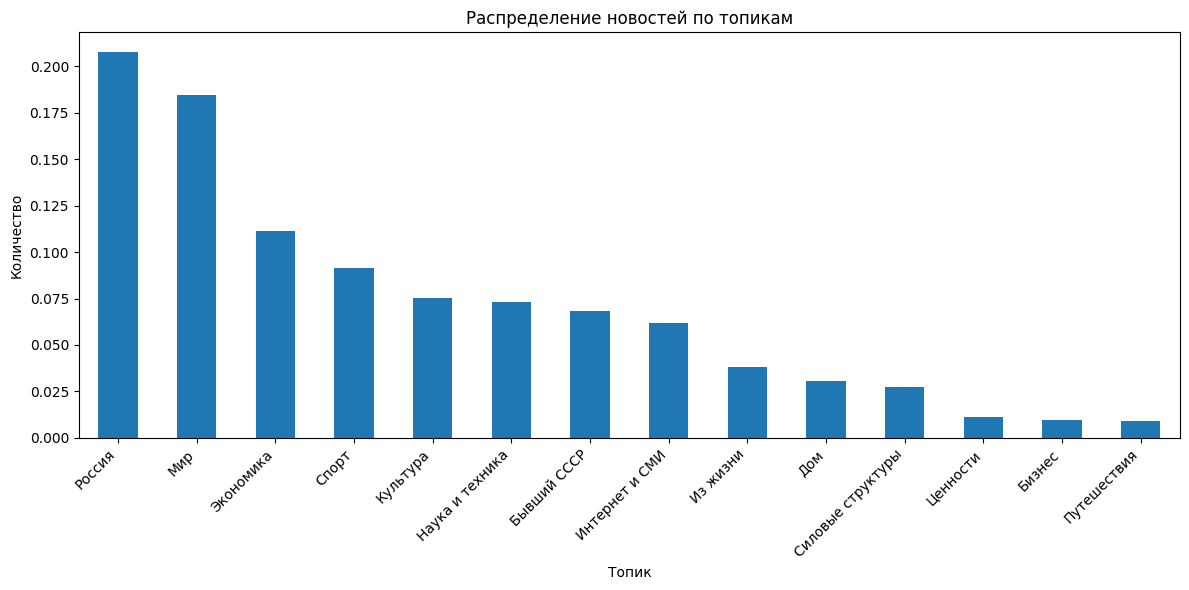

In [22]:
# Распределение классов
topic_counts = df_filtered_len['topic'].value_counts(normalize=True)
print('Распределение по топикам:')
print(topic_counts)

plt.figure(figsize=(12, 6))
topic_counts.plot(kind='bar')
plt.title('Распределение новостей по топикам')
plt.xlabel('Топик')
plt.ylabel('Количество')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Выделение репрезентативной выборки (100,000 текстов)

In [23]:
# Стратифицированная выборка для сохранения распределения классов
SAMPLE_SIZE = 100_000

df_sample, _ = train_test_split(
    df_filtered_len, 
    train_size=SAMPLE_SIZE, 
    stratify=df_filtered_len['topic'],
    random_state=RANDOM_STATE
)

print(f'Размер выборки: {len(df_sample):,}')
print(f'Распределение сохранено: {df_sample["topic"].value_counts(normalize=True)}')

Размер выборки: 100,000
Распределение сохранено: topic
Россия               0.20798
Мир                  0.18452
Экономика            0.11124
Спорт                0.09154
Культура             0.07531
Наука и техника      0.07304
Бывший СССР          0.06828
Интернет и СМИ       0.06158
Из жизни             0.03833
Дом                  0.03059
Силовые структуры    0.02748
Ценности             0.01134
Бизнес               0.00958
Путешествия          0.00919
Name: proportion, dtype: float64


<Figure size 1200x600 with 0 Axes>

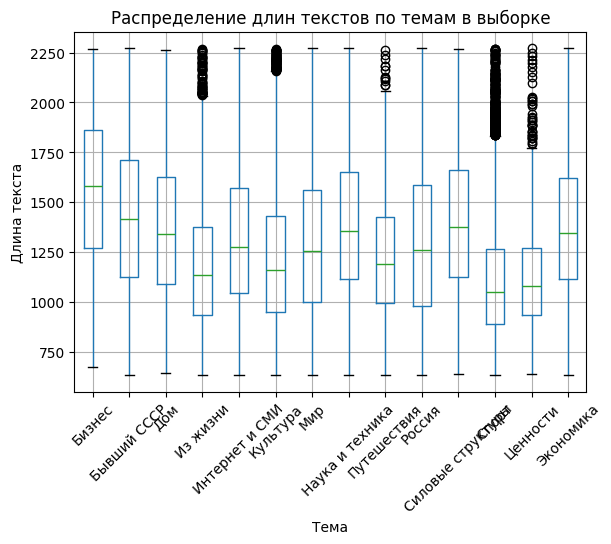

In [24]:
plt.figure(figsize=(12, 6))
df_sample.boxplot(column='text_len', by='topic', rot=45)
plt.title('Распределение длин текстов по темам в выборке')
plt.suptitle('')
plt.xlabel('Тема')
plt.ylabel('Длина текста')
plt.show()

Выборка создана, распределение по топикам и по длинам сохранено, можно переходить к предобработке текстов.

## 4. Предобработка текстов

### Выбранный пайплайн предобработки:

1. **Объединение title + text** — заголовок содержит ключевую информацию о теме
2. **Приведение к нижнему регистру** — унификация токенов
3. **Удаление URL, email, чисел** — не несут семантической информации для классификации топиков
4. **Удаление пунктуации** — упрощение токенизации
5. **Токенизация** — разбиение на слова
6. **Удаление стоп-слов** — фильтрация неинформативных слов
7. **Лемматизация (pymorphy3)** — приведение слов к нормальной форме

**Почему pymorphy3 вместо pymystem3:**
- Быстрее работает (чистый Python, без внешних бинарников)
- Проще установка
- Достаточное качество для задачи классификации

**Оптимизации:**
- Кэширование лемм через словарь
- Компиляция регулярных выражений
- Батчевая обработка с tqdm для отслеживания прогресса

In [25]:
# Инициализация морфологического анализатора
morph = pymorphy3.MorphAnalyzer()

# Кэш для лемматизации (оптимизация)
lemma_cache = {}

# Компилируем регулярные выражения заранее (оптимизация)
URL_PATTERN = re.compile(r'https?://\S+|www\.\S+')
EMAIL_PATTERN = re.compile(r'\S+@\S+')
NUMBERS_PATTERN = re.compile(r'\d+')
PUNCTUATION_PATTERN = re.compile(r'[^\w\s]')
WHITESPACE_PATTERN = re.compile(r'\s+')


def lemmatize_word(word: str) -> str:
    """Лемматизация с кэшированием."""
    if word not in lemma_cache:
        lemma_cache[word] = morph.parse(word)[0].normal_form
    return lemma_cache[word]


def preprocess_text(text: str) -> str:
    """Полный пайплайн предобработки текста."""
    if not isinstance(text, str):
        return ''
    
    # Приводим к нижнему регистру
    text = text.lower()
    
    # Удаляем URL, email, числа
    text = URL_PATTERN.sub(' ', text)
    text = EMAIL_PATTERN.sub(' ', text)
    text = NUMBERS_PATTERN.sub(' ', text)
    
    # Удаляем пунктуацию
    text = PUNCTUATION_PATTERN.sub(' ', text)
    
    # Токенизация
    tokens = text.split()
    
    # Фильтрация стоп-слов и коротких токенов + лемматизация
    tokens = [
        lemmatize_word(token) 
        for token in tokens 
        if token not in RUSSIAN_STOPWORDS and len(token) > 2
    ]
    
    return ' '.join(tokens)

In [26]:
# Пример работы предобработки
sample_text = df_sample.iloc[0]['text']
print('Исходный текст:')
print(sample_text[:500])
print()
print('После предобработки:')
print(preprocess_text(sample_text)[:500])

Исходный текст:
Тайваньская компания Asus намерена оснастить почти все выпускаемые ею материнские платы операционной системой Splashtop, использующей ядро Linux и разработанной компанией DeviceVM, пишет The Inquirer. До этого Splashtop была встроена только в наиболее дорогие системные платы. Splashtop позволяет пользователю выполнять основные задачи вроде захода на сайты, чтения электронной почты и голосового общения через интернет. При этом загрузка Splashtop занимает несколько секунд. Предполагается, что она 

После предобработки:
тайваньский компания asus намерить оснастить выпускать материнский плата операционный система splashtop использовать ядро linux разработать компания devicevm писать the inquirer splashtop встроить наиболее дорогой системный плата splashtop позволять пользователь выполнять основной задача вроде заход сайт чтение электронный почта голосовой общение интернет загрузка splashtop занимать несколько секунда предполагаться пригодиться тот случай запускать основный 

In [27]:
# Объединяем title и text, затем применяем предобработку
tqdm.pandas(desc='Предобработка текстов')

df_sample['full_text'] = df_sample['title'] + ' ' + df_sample['text']
df_sample['processed_text'] = df_sample['full_text'].progress_apply(preprocess_text)

print(f'Размер кэша лемм: {len(lemma_cache):,}')

Предобработка текстов: 100%|██████████| 100000/100000 [00:38<00:00, 2612.79it/s]

Размер кэша лемм: 425,192


In [28]:
# Кодируем целевую переменную
label_encoder = LabelEncoder()
df_sample['label'] = label_encoder.fit_transform(df_sample['topic'])

print('Маппинг классов:')
for i, cls in enumerate(label_encoder.classes_):
    print(f'{i}: {cls}')

Маппинг классов:
0: Бизнес
1: Бывший СССР
2: Дом
3: Из жизни
4: Интернет и СМИ
5: Культура
6: Мир
7: Наука и техника
8: Путешествия
9: Россия
10: Силовые структуры
11: Спорт
12: Ценности
13: Экономика


## 5. Разделение на train/val/test (60/20/20)

In [29]:
X = df_sample['processed_text'].values
y = df_sample['label'].values

# Сначала отделяем test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=RANDOM_STATE
)

# Затем делим оставшиеся 80% на train (60%) и val (20%)
# 20% от оставшихся 80% = 25% от temp
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.25,  # 0.25 * 0.8 = 0.2
    stratify=y_temp, 
    random_state=RANDOM_STATE
)

print(f'Train: {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)')
print(f'Val:   {len(X_val):,} ({len(X_val)/len(X)*100:.0f}%)')
print(f'Test:  {len(X_test):,} ({len(X_test)/len(X)*100:.0f}%)')

Train: 60,000 (60%)
Val:   20,000 (20%)
Test:  20,000 (20%)


## 6. Baseline: DummyClassifier

In [ ]:
# Для DummyClassifier не нужна векторизация — работает напрямую с метками

# Стратегия 1: всегда предсказывать самый частый класс
dummy_frequent = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy_frequent.fit(X_train, y_train)
y_pred_frequent = dummy_frequent.predict(X_val)

print('=== DummyClassifier (most_frequent) ===')
print(f'Accuracy: {accuracy_score(y_val, y_pred_frequent):.4f}')
print(f'F1 Macro: {f1_score(y_val, y_pred_frequent, average="macro"):.4f}')
print(f'F1 Weighted: {f1_score(y_val, y_pred_frequent, average="weighted"):.4f}')
print()

# Стратегия 2: случайные предсказания по распределению
dummy_stratified = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy_stratified.fit(X_train, y_train)
y_pred_stratified = dummy_stratified.predict(X_val)

# Для базовой оценки качества возьмем стандартные метрики для классификации: accuracy и два варианта f1, поскольку в классах есть дисбалланс
print('=== DummyClassifier (stratified) ===')
print(f'Accuracy: {accuracy_score(y_val, y_pred_stratified):.4f}')
print(f'F1 Macro: {f1_score(y_val, y_pred_stratified, average="macro"):.4f}')
print(f'F1 Weighted: {f1_score(y_val, y_pred_stratified, average="weighted"):.4f}')

=== DummyClassifier (most_frequent) ===
Accuracy: 0.2080
F1 Macro: 0.0246
F1 Weighted: 0.0716

=== DummyClassifier (stratified) ===
Accuracy: 0.1263
F1 Macro: 0.0744
F1 Weighted: 0.1259


## 7. LogisticRegression + CountVectorizer

In [ ]:
# Базовый пайплайн с CountVectorizer
pipeline_count = Pipeline([
    ('vectorizer', CountVectorizer(max_features=10000, ngram_range=(1, 1))),
    ('classifier', LogisticRegression(
        max_iter=1000, 
        random_state=RANDOM_STATE,
        solver='lbfgs',
        n_jobs=-1
    ))
])

pipeline_count.fit(X_train, y_train)
y_pred_count = pipeline_count.predict(X_val)

print('=== LogisticRegression + CountVectorizer ===')
print(f'Accuracy: {accuracy_score(y_val, y_pred_count):.4f}')
print(f'F1 Macro: {f1_score(y_val, y_pred_count, average="macro"):.4f}')
print(f'F1 Weighted: {f1_score(y_val, y_pred_count, average="weighted"):.4f}')

=== LogisticRegression + CountVectorizer ===
Accuracy: 0.7854
F1 Macro: 0.7431
F1 Weighted: 0.7848


## 8. LogisticRegression + TfidfVectorizer

In [ ]:
# Базовый пайплайн с TfidfVectorizer
pipeline_tfidf = Pipeline([
    ('vectorizer', TfidfVectorizer(max_features=10000, ngram_range=(1, 1))),
    ('classifier', LogisticRegression(
        max_iter=1000, 
        random_state=RANDOM_STATE,
        solver='lbfgs',
        n_jobs=-1
    ))
])

pipeline_tfidf.fit(X_train, y_train)
y_pred_tfidf = pipeline_tfidf.predict(X_val)

print('=== LogisticRegression + TfidfVectorizer ===')
print(f'Accuracy: {accuracy_score(y_val, y_pred_tfidf):.4f}')
print(f'F1 Macro: {f1_score(y_val, y_pred_tfidf, average="macro"):.4f}')
print(f'F1 Weighted: {f1_score(y_val, y_pred_tfidf, average="weighted"):.4f}')

=== LogisticRegression + TfidfVectorizer ===
Accuracy: 0.8156
F1 Macro: 0.7426
F1 Weighted: 0.8105


## 9. Подбор гиперпараметров (GridSearchCV)

In [35]:
# Определяем пространство поиска гиперпараметров
# Используем TfidfVectorizer как базу, т.к. с ним получены лучшие метрики 

pipeline_search = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('classifier', LogisticRegression(
        max_iter=1000, 
        random_state=RANDOM_STATE,
        solver='lbfgs',
        n_jobs=-1
    ))
])

param_grid = {
    'vectorizer__max_features': [10000, 20000],
    'vectorizer__ngram_range': [(1, 1), (1, 2)],
    'vectorizer__min_df': [2, 5],
    'vectorizer__sublinear_tf': [True, False],
    'classifier__C': [0.1, 1.0, 10.0],
    'classifier__class_weight': [None, 'balanced']
}

# Стратифицированная кросс-валидация
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    pipeline_search,
    param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

print('Запуск GridSearchCV...')
grid_search.fit(X_train, y_train)

Запуск GridSearchCV...
Fitting 3 folds for each of 96 candidates, totalling 288 fits


[CV] END classifier__C=0.1, classifier__class_weight=None, vectorizer__max_features=10000, vectorizer__min_df=2, vectorizer__ngram_range=(1, 1), vectorizer__sublinear_tf=True; total time=  10.9s
[CV] END classifier__C=0.1, classifier__class_weight=None, vectorizer__max_features=10000, vectorizer__min_df=2, vectorizer__ngram_range=(1, 1), vectorizer__sublinear_tf=False; total time=  10.5s
[CV] END classifier__C=0.1, classifier__class_weight=None, vectorizer__max_features=10000, vectorizer__min_df=2, vectorizer__ngram_range=(1, 1), vectorizer__sublinear_tf=False; total time=  11.5s
[CV] END classifier__C=0.1, classifier__class_weight=None, vectorizer__max_features=10000, vectorizer__min_df=2, vectorizer__ngram_range=(1, 1), vectorizer__sublinear_tf=False; total time=  11.0s
[CV] END classifier__C=0.1, classifier__class_weight=None, vectorizer__max_features=10000, vectorizer__min_df=2, vectorizer__ngram_range=(1, 1), vectorizer__sublinear_tf=True; total time=  12.0s
[CV] END classifier__C

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.1, 1.0, ...], 'classifier__class_weight': [None, 'balanced'], 'vectorizer__max_features': [10000, 20000], 'vectorizer__min_df': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, 

In [36]:
print('Лучшие параметры:')
print(grid_search.best_params_)
print()
print(f'Лучший F1 Macro на CV: {grid_search.best_score_:.4f}')

Лучшие параметры:
{'classifier__C': 10.0, 'classifier__class_weight': 'balanced', 'vectorizer__max_features': 20000, 'vectorizer__min_df': 5, 'vectorizer__ngram_range': (1, 2), 'vectorizer__sublinear_tf': True}

Лучший F1 Macro на CV: 0.7817


In [37]:
# Оценка лучшей модели на валидации
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_val)

print('=== Лучшая модель на валидации ===')
print(f'Accuracy: {accuracy_score(y_val, y_pred_best):.4f}')
print(f'F1 Macro: {f1_score(y_val, y_pred_best, average="macro"):.4f}')
print(f'F1 Weighted: {f1_score(y_val, y_pred_best, average="weighted"):.4f}')

=== Лучшая модель на валидации ===
Accuracy: 0.8202
F1 Macro: 0.7831
F1 Weighted: 0.8211


## 10. Финальная оценка на тестовой выборке

In [38]:
# Переобучаем лучшую модель на train + val
X_train_full = np.concatenate([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

# Создаем финальную модель с лучшими параметрами
final_model = Pipeline([
    ('vectorizer', TfidfVectorizer(**{
        k.replace('vectorizer__', ''): v 
        for k, v in grid_search.best_params_.items() 
        if k.startswith('vectorizer__')
    })),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        solver='lbfgs',
        **{
            k.replace('classifier__', ''): v 
            for k, v in grid_search.best_params_.items() 
            if k.startswith('classifier__')
        }
    ))
])

final_model.fit(X_train_full, y_train_full)
y_pred_test = final_model.predict(X_test)

print('=== ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ НА ТЕСТЕ ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_test):.4f}')
print(f'F1 Macro: {f1_score(y_test, y_pred_test, average="macro"):.4f}')
print(f'F1 Weighted: {f1_score(y_test, y_pred_test, average="weighted"):.4f}')

=== ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ НА ТЕСТЕ ===
Accuracy: 0.8256
F1 Macro: 0.7931
F1 Weighted: 0.8266


## 11. Анализ ошибок

In [39]:
# Classification Report
print('Classification Report:')
print(classification_report(
    y_test, 
    y_pred_test, 
    target_names=label_encoder.classes_
))

Classification Report:
                   precision    recall  f1-score   support

           Бизнес       0.54      0.62      0.57       192
      Бывший СССР       0.81      0.87      0.84      1366
              Дом       0.81      0.88      0.84       612
         Из жизни       0.60      0.69      0.64       767
   Интернет и СМИ       0.75      0.76      0.75      1231
         Культура       0.88      0.88      0.88      1506
              Мир       0.84      0.83      0.83      3690
  Наука и техника       0.84      0.85      0.84      1461
      Путешествия       0.73      0.72      0.73       184
           Россия       0.85      0.77      0.81      4159
Силовые структуры       0.60      0.71      0.65       549
            Спорт       0.97      0.96      0.97      1831
         Ценности       0.93      0.87      0.90       227
        Экономика       0.85      0.85      0.85      2225

         accuracy                           0.83     20000
        macro avg       0.78   

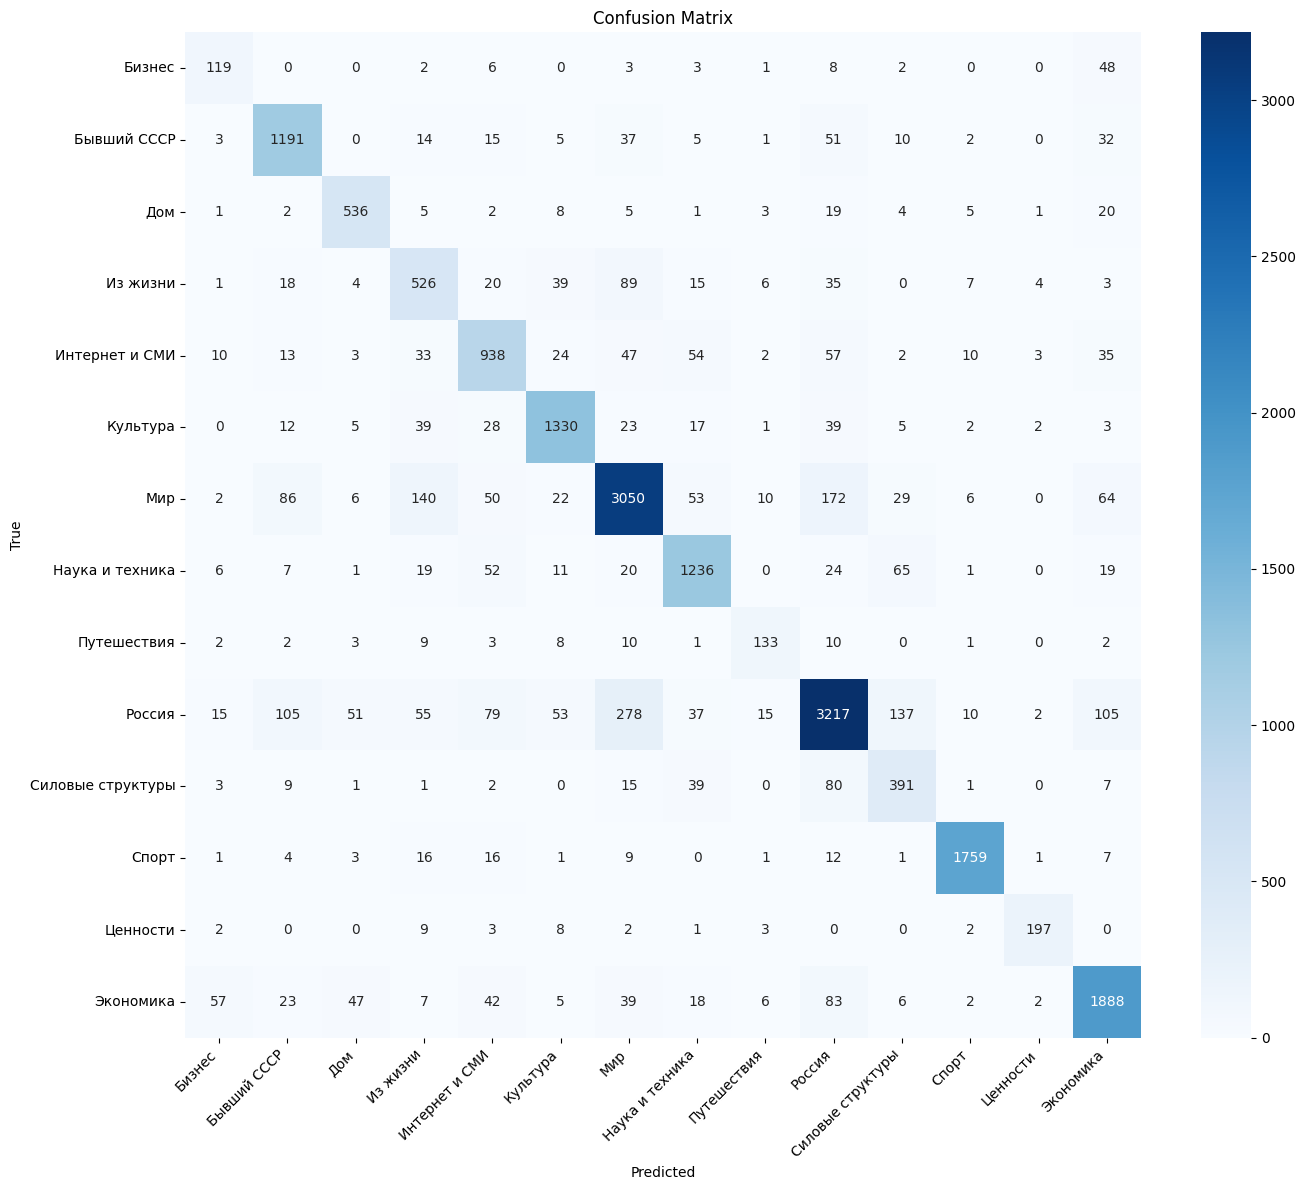

In [40]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

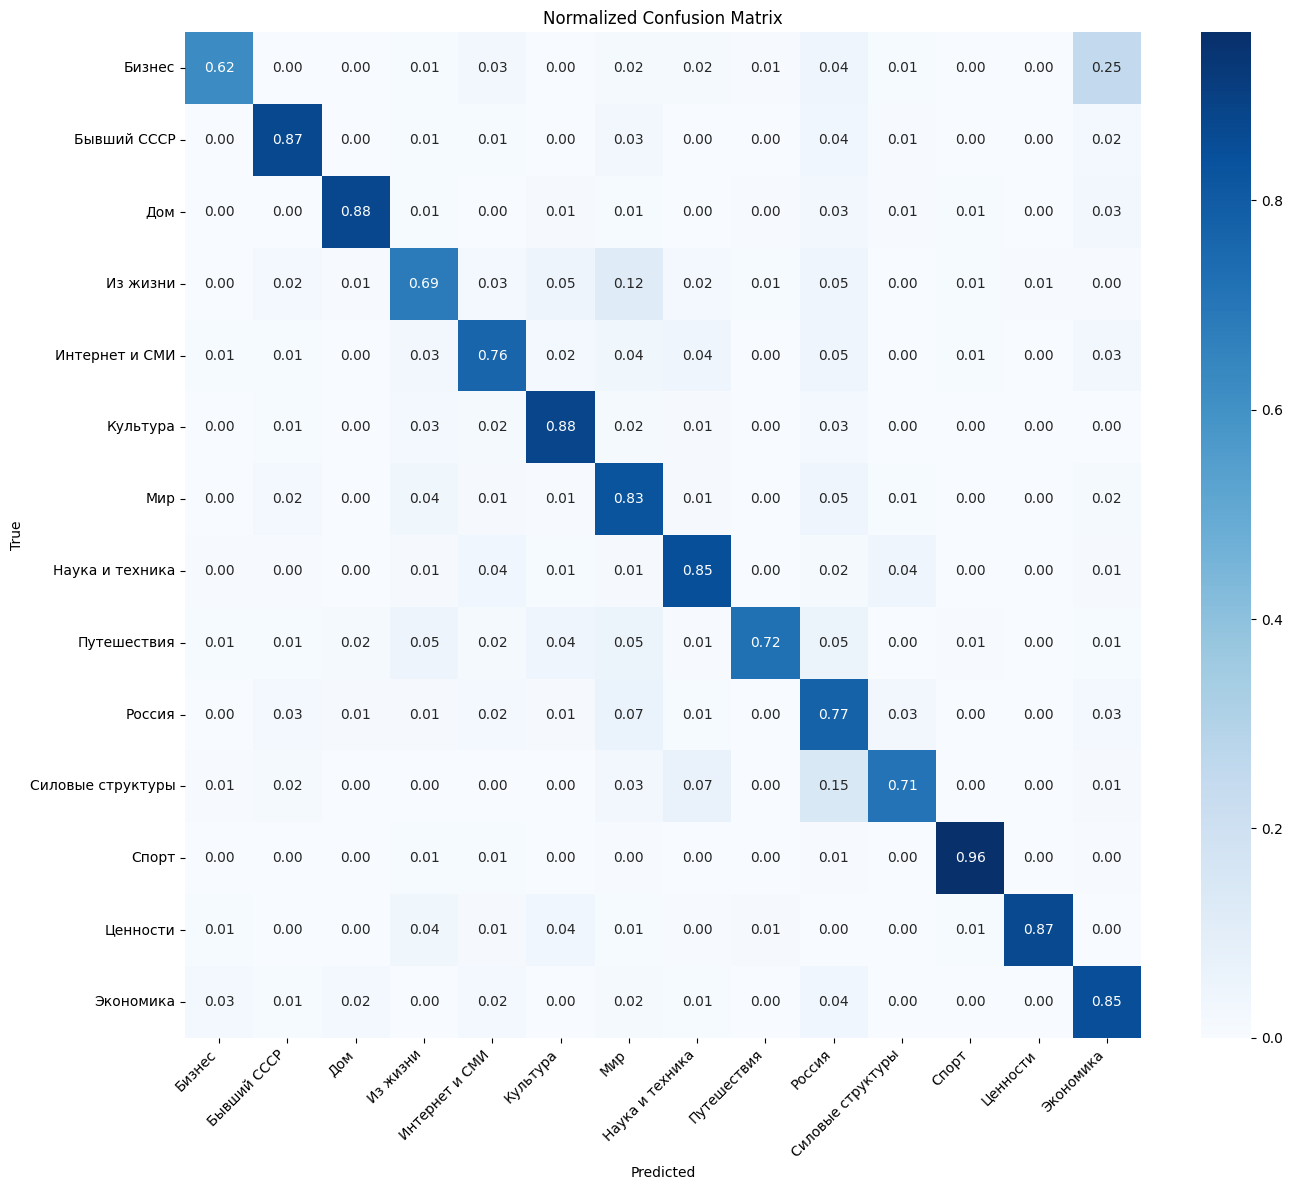

In [41]:
# Нормализованная Confusion Matrix (по строкам)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_normalized, 
    annot=True, 
    fmt='.2f', 
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title('Normalized Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [42]:
# Анализ наиболее путаемых классов
# Находим пары классов с наибольшим числом ошибок
np.fill_diagonal(cm, 0)  # Убираем диагональ

# Топ-10 пар с наибольшим количеством ошибок
pairs = []
for i in range(len(label_encoder.classes_)):
    for j in range(len(label_encoder.classes_)):
        if i != j and cm[i, j] > 0:
            pairs.append((
                label_encoder.classes_[i],
                label_encoder.classes_[j],
                cm[i, j]
            ))

pairs.sort(key=lambda x: x[2], reverse=True)
print('Топ-10 наиболее частых ошибок (True -> Predicted):')
for true_cls, pred_cls, count in pairs[:10]:
    print(f'  {true_cls} -> {pred_cls}: {count}')

Топ-10 наиболее частых ошибок (True -> Predicted):
  Россия -> Мир: 278
  Мир -> Россия: 172
  Мир -> Из жизни: 140
  Россия -> Силовые структуры: 137
  Россия -> Бывший СССР: 105
  Россия -> Экономика: 105
  Из жизни -> Мир: 89
  Мир -> Бывший СССР: 86
  Экономика -> Россия: 83
  Силовые структуры -> Россия: 80


In [43]:
# Примеры неправильных предсказаний
test_df = df_sample.iloc[df_sample.index.isin(
    df_sample.index[len(X_train) + len(X_val):]
)].copy()

# Находим индексы ошибок
errors_idx = np.where(y_test != y_pred_test)[0]
print(f'Всего ошибок: {len(errors_idx)} из {len(y_test)} ({len(errors_idx)/len(y_test)*100:.1f}%)')
print()

# Показываем несколько примеров
print('Примеры ошибок:')
for idx in errors_idx[:5]:
    true_label = label_encoder.classes_[y_test[idx]]
    pred_label = label_encoder.classes_[y_pred_test[idx]]
    text = X_test[idx][:200]
    print(f'True: {true_label}')
    print(f'Pred: {pred_label}')
    print(f'Text: {text}...')
    print('-' * 50)

Всего ошибок: 3489 из 20000 (17.4%)

Примеры ошибок:
True: Мир
Pred: Бывший СССР
Text: ющенко пустить янукович новый правительство виктор ющенко отрицать возможность работа виктор янукович кабинет министр украина случай свой победа президентский выборы декабрь сообщать корреспондент net...
--------------------------------------------------
True: Из жизни
Pred: Мир
Text: власть таиланд объявить война таракан министерство здравоохранение таиланд приказать срочно дезинфицировать общественный автобус очистить таракан насекомое заползти один пассажир ухо сообщать der spie...
--------------------------------------------------
True: Интернет и СМИ
Pred: Россия
Text: сенатор призвать совет федерация ответить массовый оскорбление сторона сми член совет федерация тамбовский область евгений тарло заседание совет январь заявить сенатор должный выпустить информационный...
--------------------------------------------------
True: Бизнес
Pred: Экономика
Text: россия запретить ввоз тонна американский к

## 12. Выводы

### Результаты:

| Модель | Accuracy | F1 Macro | F1 Weighted |
|--------|----------|----------|-------------|
| DummyClassifier (most_frequent) | 0.2080 | 0.0246 | 0.0716 |
| DummyClassifier (stratified) | 0.1263 | 0.0744 | 0.1259 |
| CountVectorizer + LR | 0.7854 | 0.7431 | 0.7848 |
| TfidfVectorizer + LR | 0.8156 | 0.7426 | 0.8105 |
| Best Model (tuned, test) | **0.8256** | **0.7931** | **0.8266** |

### Основные наблюдения:

1. **TF-IDF vs Count:** TF-IDF показал лучшие результаты по Accuracy (+3%) и F1 Weighted (+2.6%), при этом F1 Macro практически одинаков. TF-IDF лучше справляется с взвешиванием важности слов, понижая вес частых неинформативных термов.

2. **Влияние гиперпараметров:**
   - `ngram_range=(1, 2)` — биграммы улучшают качество, захватывая контекст (например, "силовые структуры", "бывший СССР")
   - `sublinear_tf=True` — логарифмическое масштабирование частот снижает влияние очень частых слов
   - `class_weight='balanced'` — балансировка классов улучшила F1 Macro на ~5%, компенсируя дисбаланс
   - `C=10.0` — меньшая регуляризация позволила модели лучше подстроиться под данные
   - `max_features=20000` — расширение словаря дало больше признаков для различения классов

3. **Анализ ошибок:**
   - Наиболее путаемые пары: **Россия ↔ Мир** (450 ошибок суммарно) — семантически близкие категории, новости о международных отношениях России
   - **Россия → Силовые структуры** (137): новости о силовиках в контексте внутренней политики
   - **Россия ↔ Бывший СССР** (191): пересечение тематик постсоветского пространства
   - **Бизнес ↔ Экономика**: низкая precision у "Бизнес" (0.54) из-за малого размера класса (958 примеров) и семантической близости с "Экономика"
   - Лучшие результаты у **Спорт** (F1=0.97) и **Ценности** (F1=0.90) — чётко выраженная специфическая лексика

### Возможные улучшения:

1. Объединение семантически близких классов (Россия/Мир/Бывший СССР) или иерархическая классификация
2. Использование эмбеддингов (FastText, Word2Vec) для учёта семантической близости слов
3. Более сложные модели (SVM с RBF-ядром, градиентный бустинг)
4. Аугментация данных для малых классов (Бизнес, Путешествия, Ценности)